In [21]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(1)

In [22]:
from pathlib import Path
import h5py

diagnostics_path = Path("data/test_bursting_diagnostics_0.25.h5")

if not diagnostics_path.exists():
    raise FileNotFoundError("Run `python run_test_diagnostics.py` first to generate diagnostics data.")

with h5py.File(diagnostics_path, "r") as f:
    completed_step = int(f.attrs.get("completed_step", len(f["time/t"]) - 1))
    data_slice = slice(0, completed_step + 1)
    error_slice = slice(0, completed_step)
    
    t = f["time/t"][data_slice]
    
    gamma_data = {key: f[f"gamma_1000/{key}"][data_slice] for key in f["gamma_1000"]}
    gamma0_data = {key: f[f"gamma_0/{key}"][data_slice] for key in f["gamma_0"]}
    ref_data = {key: f[f"etdrk4_ref/{key}"][data_slice] for key in f["etdrk4_ref"]}
    
    l2_error_gamma = f["errors/l2_error_gamma_1000"][error_slice]
    l2_error_gamma0 = f["errors/l2_error_gamma_0"][error_slice]
    rel_l2_gamma = f["errors/rel_l2_gamma_1000"][error_slice]
    rel_l2_gamma0 = f["errors/rel_l2_gamma_0"][error_slice]

enstrophy_gamma = gamma_data["Enstrophy"]
enstrophy_gamma0 = gamma0_data["Enstrophy"]
enstrophy_ref = ref_data["Enstrophy"]

q_gamma = gamma_data["q"]
q_gamma0 = gamma0_data["q"]
q_dev_gamma = np.abs(q_gamma - 1.0)
q_dev_gamma0 = np.abs(q_gamma0 - 1.0)

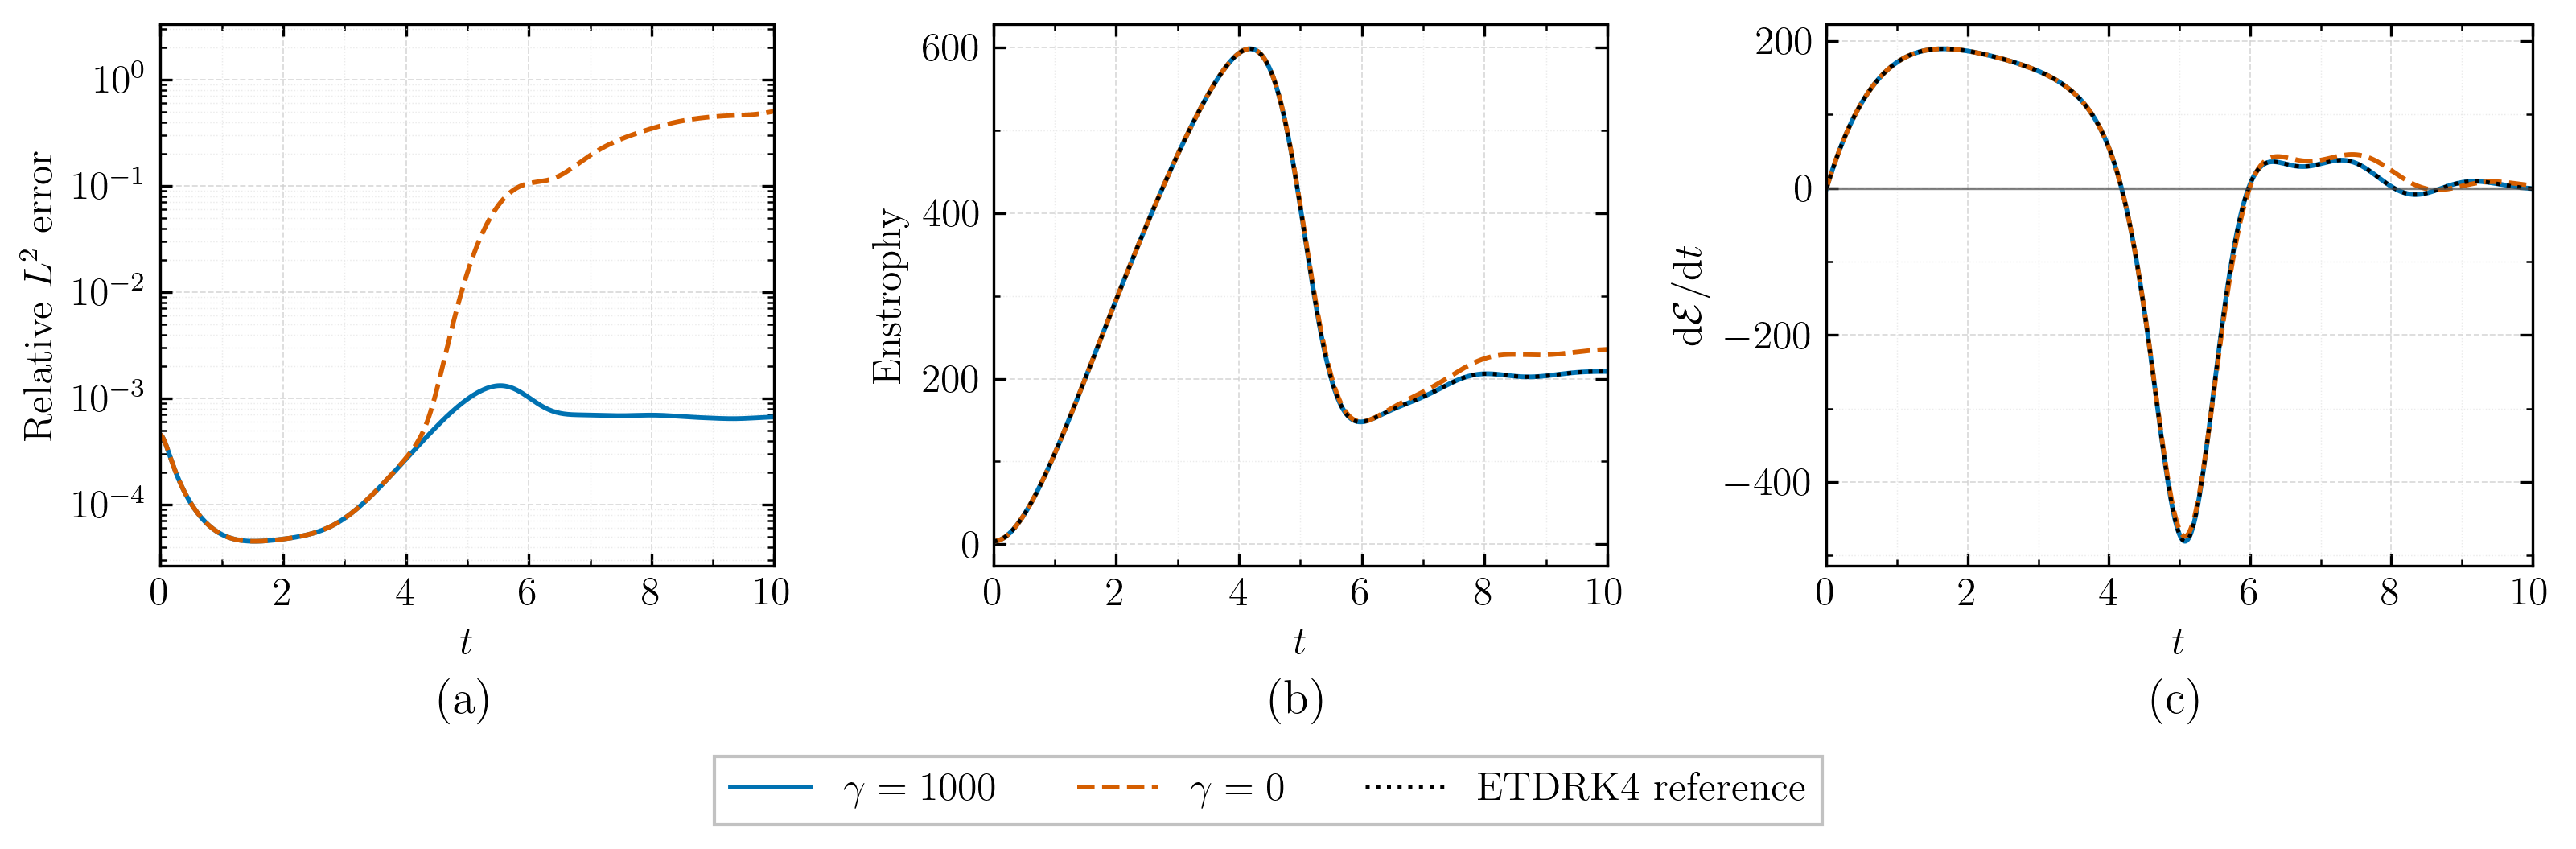

In [34]:
from pathlib import Path
import matplotlib as mpl
from matplotlib.ticker import AutoMinorLocator, LogLocator, MultipleLocator

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.family": "Time New Roman",
    "font.size": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

# Publication-ready styling: vector-friendly fonts, compact journal width,
# colorblind-safe colors, and redundant line/marker encodings.
okabe_ito = {
    "blue": "#0072B2",
    "orange": "#D55E00",
    "green": "#009E73",
    "purple": "#CC79A7",
    "black": "#000000",
}

fig, axes = plt.subplots(
    1, 3,
    figsize=(10.8, 3.4),
    dpi=300,
    gridspec_kw={"width_ratios": [1.0, 1.0, 1.15]},
)
ax0, ax2, ax3 = axes

# A: relative L2 error against ETDRK4
ax0.semilogy(t[1:], rel_l2_gamma, color=okabe_ito["blue"], lw=1.4,
             label=r"$\gamma=1000$")
ax0.semilogy(t[1:], rel_l2_gamma0, color=okabe_ito["orange"], lw=1.4,
             ls="--", label=r"$\gamma=0$")
ax0.set_xlabel(r"$t$")
ax0.set_ylabel(r"Relative $L^2$ error")
ax0.set_xlim(left=0, right=10)
ax0.yaxis.set_major_locator(LogLocator(base=10))
ax0.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))


# C: enstrophy evolution
ax2.plot(t[1:], enstrophy_gamma[1:], color=okabe_ito["blue"], lw=1.4, label=r"$\gamma=1000$")
ax2.plot(t[1:], enstrophy_gamma0[1:], color=okabe_ito["orange"], lw=1.4, ls="--", label=r"$\gamma=0$")
ax2.plot(t[1:], enstrophy_ref[1:], color=okabe_ito["black"], lw=1.2, ls=":", label="ETDRK4 reference")
ax2.set_xlabel(r"$t$")
ax2.set_ylabel(r"Enstrophy")
ax2.set_xlim(left=0, right=10)
ax2.yaxis.set_minor_locator(AutoMinorLocator(2))

# D: enstrophy rate of change

def enstrophy_rate(time, enstrophy):
    time = np.asarray(time)
    enstrophy = np.asarray(enstrophy)
    return 0.5 * (time[1:] + time[:-1]), np.diff(enstrophy) / np.diff(time)


t_rate_gamma, enstrophy_rate_gamma = enstrophy_rate(t, enstrophy_gamma)
t_rate_gamma0, enstrophy_rate_gamma0 = enstrophy_rate(t, enstrophy_gamma0)
t_rate_ref, enstrophy_rate_ref = enstrophy_rate(t, enstrophy_ref)

ax3.plot(t_rate_gamma, enstrophy_rate_gamma, color=okabe_ito["blue"], lw=1.4,
         label=r"$\gamma=1000$")
ax3.plot(t_rate_gamma0, enstrophy_rate_gamma0, color=okabe_ito["orange"], lw=1.4,
         ls="--", label=r"$\gamma=0$")
ax3.plot(t_rate_ref, enstrophy_rate_ref, color=okabe_ito["black"], lw=1.2,
         ls=":", label="ETDRK4 reference")
ax3.axhline(0.0, color="0.3", lw=0.8, alpha=0.7)
ax3.set_xlabel(r"$t$")
ax3.set_ylabel(r"$\mathrm{d}\mathcal{E}/\mathrm{d}t$")
ax3.set_xlim(left=0, right=10)
ax3.yaxis.set_minor_locator(AutoMinorLocator(2))

for ax in [ax0, ax2, ax3]:
    ax.xaxis.set_major_locator(MultipleLocator(2))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.grid(True, which="major", color="0.82", linestyle="--", linewidth=0.45, alpha=0.75)
    ax.grid(True, which="minor", color="0.90", linestyle=":", linewidth=0.35, alpha=0.80)

for label, ax in zip(["(a)", "(b)", "(c)"], [ax0, ax2, ax3]):
    ax.text(0.5, -0.25, label, transform=ax.transAxes,
            fontsize=14, fontweight="bold", ha="center", va="center")

handles, labels = [], []
for ax in [ax0,  ax2, ax3]:
    ax_handles, ax_labels = ax.get_legend_handles_labels()
    for handle, label in zip(ax_handles, ax_labels):
        if label not in labels:
            handles.append(handle)
            labels.append(label)

fig.legend(handles, labels, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.06), framealpha=0.95,
           edgecolor="0.75", fancybox=False)

fig.subplots_adjust(left=0.075, right=0.985, bottom=0.28, top=0.94, wspace=0.34)
fig.savefig("./fig/mrSAV_comparison_publication.pdf")
# fig.savefig("./fig/mrSAV_comparison_publication.png", dpi=600)
plt.show()


In [31]:
import pandas as pd

comparison_times = np.array([4.0, 6.0, 8.0, 10.0])
metrics = [
    ("rel_l2", r"$e_\omega$"),
    ("rel_enstrophy", r"$e_{\mathcal{E}}$"),
    ("rel_enstrophy_rate", r"$e_{\dot{\mathcal{E}}}$"),
]


def nearest_time_index(time_grid, target, atol=1e-12):
    idx = int(np.argmin(np.abs(time_grid - target)))
    if not np.isclose(time_grid[idx], target, rtol=0.0, atol=atol):
        raise ValueError(f"No saved diagnostic at t={target}.")
    return idx


def sci_notation(value, precision=2, bold=False):
    if not np.isfinite(value):
        return r"--"
    if value == 0:
        text = "0"
    else:
        exponent = int(np.floor(np.log10(abs(value))))
        mantissa = value / 10**exponent
        text = rf"{mantissa:.{precision}f}\times 10^{{{exponent}}}"
    return rf"$\mathbf{{{text}}}$" if bold else rf"${text}$"


method_data = {
    r"$\gamma=1000$": {
        "rel_l2": rel_l2_gamma,
        "enstrophy": enstrophy_gamma,
        "enstrophy_rate": np.gradient(enstrophy_gamma, t),
    },
    r"$\gamma=0$": {
        "rel_l2": rel_l2_gamma0,
        "enstrophy": enstrophy_gamma0,
        "enstrophy_rate": np.gradient(enstrophy_gamma0, t),
    },
}
enstrophy_rate_ref_grid = np.gradient(enstrophy_ref, t)

wide_rows = []
latex_rows = []
for target_time in comparison_times:
    t_idx = nearest_time_index(t, target_time)
    err_idx = t_idx - 1
    if err_idx < 0:
        raise ValueError("Relative L2 errors are stored for t[1:] only.")

    ref_ens = enstrophy_ref[t_idx]
    ref_ens_rate = enstrophy_rate_ref_grid[t_idx]
    row = {"Time": int(round(t[t_idx]))}
    raw_values = {}

    for method, values in method_data.items():
        raw_values[(method, "rel_l2")] = values["rel_l2"][err_idx]
        raw_values[(method, "rel_enstrophy")] = abs(values["enstrophy"][t_idx] - ref_ens) / abs(ref_ens)
        raw_values[(method, "rel_enstrophy_rate")] = abs(values["enstrophy_rate"][t_idx] - ref_ens_rate) / abs(ref_ens_rate)

    for metric_key, metric_label in metrics:
        metric_values = [raw_values[(method, metric_key)] for method in method_data]
        best = int(np.nanargmin(metric_values))
        for method_idx, method in enumerate(method_data):
            value = raw_values[(method, metric_key)]
            row[(method, metric_label)] = f"{value:.2e}"
            raw_values[(method, metric_key, "latex")] = sci_notation(value, bold=(method_idx == best))

    row = {
        "Time": row["Time"],
        **{(method, metric_label): row[(method, metric_label)] for method in method_data for _, metric_label in metrics},
    }

    wide_rows.append(row)
    latex_rows.append([
        str(row["Time"]),
        raw_values[(r"$\gamma=1000$", "rel_l2", "latex")],
        raw_values[(r"$\gamma=1000$", "rel_enstrophy", "latex")],
        raw_values[(r"$\gamma=1000$", "rel_enstrophy_rate", "latex")],
        raw_values[(r"$\gamma=0$", "rel_l2", "latex")],
        raw_values[(r"$\gamma=0$", "rel_enstrophy", "latex")],
        raw_values[(r"$\gamma=0$", "rel_enstrophy_rate", "latex")],
    ])

preview_table = pd.DataFrame(wide_rows)
preview_table.columns = pd.MultiIndex.from_tuples(
    [("", "Time")] + list(preview_table.columns[1:])
)
display(preview_table)

latex_lines = [
    r"\begin{table}[htbp]",
    r"\centering",
    r"\caption{Comparison of relative vorticity, enstrophy, and enstrophy-rate errors at selected times for the mean-reverting and non-mean-reverting SAV schemes. All errors are measured relative to the ETDRK4 reference solution.}",
    r"\label{tab:mean_reverting_error_comparison}",
    r"\begin{threeparttable}",
    r"\begin{tabular}{c ccc ccc}",
    r"\toprule",
    r"\multirow{2}{*}{$t$} & \multicolumn{3}{c}{$\gamma=1000$} & \multicolumn{3}{c}{$\gamma=0$} \\",
    r"\cmidrule(lr){2-4} \cmidrule(lr){5-7}",
    r"& $e_\omega$ & $e_{\mathcal{E}}$ & $e_{\dot{\mathcal{E}}}$ & $e_\omega$ & $e_{\mathcal{E}}$ & $e_{\dot{\mathcal{E}}}$ \\",
    r"\midrule",
]
for row in latex_rows:
    latex_lines.append(" & ".join(row) + r" \\")
latex_lines += [
    r"\bottomrule",
    r"\end{tabular}",
    r"\begin{tablenotes}",
    r"\footnotesize",
    r"\item Note: $e_\omega=\|\omega_h-\omega_{\rm ref}\|_2/\|\omega_{\rm ref}\|_2$, $e_{\mathcal{E}}=|\mathcal{E}_h-\mathcal{E}_{\rm ref}|/|\mathcal{E}_{\rm ref}|$, and $e_{\dot{\mathcal{E}}}=|\dot{\mathcal{E}}_h-\dot{\mathcal{E}}_{\rm ref}|/|\dot{\mathcal{E}}_{\rm ref}|$. The smaller error at each time and for each metric is shown in bold.",
    r"\end{tablenotes}",
    r"\end{threeparttable}",
    r"\end{table}",
]

print("\n".join(latex_lines))


$\gamma=1000$                                           $\gamma=0$  \
  Time    $e_\omega$ $e_{\mathcal{E}}$ $e_{\dot{\mathcal{E}}}$ $e_\omega$   
0    4      2.68e-04          1.48e-07                4.28e-05   2.75e-04   
1    6      1.02e-03          2.27e-07                2.21e-04   1.06e-01   
2    8      6.95e-04          1.50e-05                3.46e-03   3.47e-01   
3   10      6.68e-04          7.06e-05                1.16e-02   5.07e-01   

                                             
  $e_{\mathcal{E}}$ $e_{\dot{\mathcal{E}}}$  
0          2.64e-06                2.73e-04  
1          1.48e-03                6.21e-01  
2          8.92e-02                9.49e+00  
3          1.28e-01                5.67e+00

\begin{table}[htbp]
\centering
\caption{Comparison of relative vorticity, enstrophy, and enstrophy-rate errors at selected times for the mean-reverting and non-mean-reverting SAV schemes. All errors are measured relative to the ETDRK4 reference solution.}
\label{tab:mean_reverting_error_comparison}
\begin{threeparttable}
\begin{tabular}{c ccc ccc}
\toprule
\multirow{2}{*}{$t$} & \multicolumn{3}{c}{$\gamma=1000$} & \multicolumn{3}{c}{$\gamma=0$} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7}
& $e_\omega$ & $e_{\mathcal{E}}$ & $e_{\dot{\mathcal{E}}}$ & $e_\omega$ & $e_{\mathcal{E}}$ & $e_{\dot{\mathcal{E}}}$ \\
\midrule
4 & $\mathbf{2.68\times 10^{-4}}$ & $\mathbf{1.48\times 10^{-7}}$ & $\mathbf{4.28\times 10^{-5}}$ & $2.75\times 10^{-4}$ & $2.64\times 10^{-6}$ & $2.73\times 10^{-4}$ \\
6 & $\mathbf{1.02\times 10^{-3}}$ & $\mathbf{2.27\times 10^{-7}}$ & $\mathbf{2.21\times 10^{-4}}$ & $1.06\times 10^{-1}$ & $1.48\times 10^{-3}$ & $6.21\times 10^{-1}$ \\
8 & $\mathbf{6.95\times 10^{-4}}$ & $\ma

\begin{exm}\label{exm:mean_reverting_test}[Mean-reverting SAV correction]
We consider the vorticity--streamfunction equation on the periodic domain $\Omega=(0,2\pi)^2$ with viscosity $\nu=40$ and forcing term $f=4\cos(4x)$. The initial condition is generated from the isotropic perturbation streamfunction in \eqref{eqn:iso_pertbation} with perturbation amplitude $\varepsilon=0.25$. The spatial discretization uses $256$ Fourier modes. To isolate the effect of the mean-reverting mechanism, we compare the same second-order ETD-mr-SAV discretization with $\gamma=1000$ and $\gamma=0$ under the time step $\tau=10^{-3}$. An ETDRK4 computation with the finer time step $\tau_{\rm ref}=5\times10^{-4}$ is used as the reference solution.
\end{exm}

Figure~\ref{fig:mean_reverting_diagnostics} compares the relative vorticity error, the enstrophy evolution, and the enstrophy production rate for the two choices of $\gamma$. The mean-reverting correction substantially improves the accuracy of the numerical solution. With $\gamma=1000$, the relative $L^2$ error remains small throughout the displayed interval, whereas the non-mean-reverting computation with $\gamma=0$ develops a much larger deviation from the ETDRK4 reference. This contrast is also visible in Table~\ref{tab:mean_reverting_error_comparison}: at $t=10$, the relative vorticity error is $6.68\times10^{-4}$ for $\gamma=1000$, but increases to $5.07\times10^{-1}$ when the mean-reverting term is removed. The same trend appears at the earlier sampling times, showing that the gain is not a transient artifact of a single time level.

The enstrophy diagnostics give useful additional information, but they should not be interpreted as direct error indicators for the full vorticity field. Although the $\gamma=1000$ scheme also tracks the reference enstrophy and enstrophy production more accurately than the $\gamma=0$ scheme, the enstrophy errors do not vary in the same way as the relative $L^2$ error. Thus, a solution may have a small global enstrophy error while still accumulating phase or structural error in the vorticity field. This suggests that enstrophy and its rate of change are better used as supplementary stability diagnostics, rather than as the sole basis for adaptive time-stepping control.

\begin{figure}[htbp]
\centering
\includegraphics[width=0.9\linewidth]{figure/mrSAV_comparison_publication.pdf}
\caption{Effect of the mean-reverting correction on the forced periodic vorticity problem. 
(a) Relative $L^2$ error of the vorticity with respect to the ETDRK4 reference solution. 
(b) Enstrophy evolution for the reference solution and the two ETD-mr-SAV variants. 
(c) Enstrophy production rate $\mathrm{d}\mathcal{E}/\mathrm{d}t$. 
The case $\gamma=1000$ remains close to the reference solution, whereas the case $\gamma=0$ develops substantially larger solution error.}
\label{fig:mean_reverting_diagnostics}
\end{figure}

% Table~\ref{tab:mean_reverting_error_comparison} is generated by the preceding code cell.
